In [55]:
# setup
%load_ext autoreload
%autoreload 2

import sys
from importlib import reload
import src.config as config
from src.config import load_parts_by_name, load_resource_lookup, load_part_lists
from src.genetic_algorithm import run_ga
from src.plots import plot_run
from datetime import datetime

sys.path.insert(0, '...')
reload(config)


parts_by_name = load_parts_by_name()
resource_lookup = load_resource_lookup()
pods, tanks, engines, decouplers = load_part_lists(parts_by_name)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
# run
run_dir = f"../data/runs/run_{datetime.now().strftime('%Y-%m-%d-%H%M%S')}"

result = run_ga(
    n_rockets=100,
    n_generations=50,
    parts_by_name=parts_by_name,
    resource_lookup=resource_lookup,
    pods=pods,
    tanks=tanks,
    engines=engines,
    decouplers=decouplers,
    max_stages=5,
    n_elites=5,
    mutation_rate=0.4,
    detailed=True,
    save_dir=run_dir,
)

scores = [meta['score'] for _, meta in result]
print(f"best:    {max(scores):.0f} m/s")
print(f"mean:    {sum(scores) / len(scores):.0f} m/s")
print(f"nonzero: {sum(1 for s in scores if s > 0)}/{len(scores)}")

saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_000.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_001.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_002.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_003.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_004.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_005.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_006.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_007.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_008.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_009.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_010.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_011.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_012.json
saved 100 rockets to ../data/runs/run_2026-04-08-215059/gen_013.json
saved 100 rockets to ../data/runs/

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


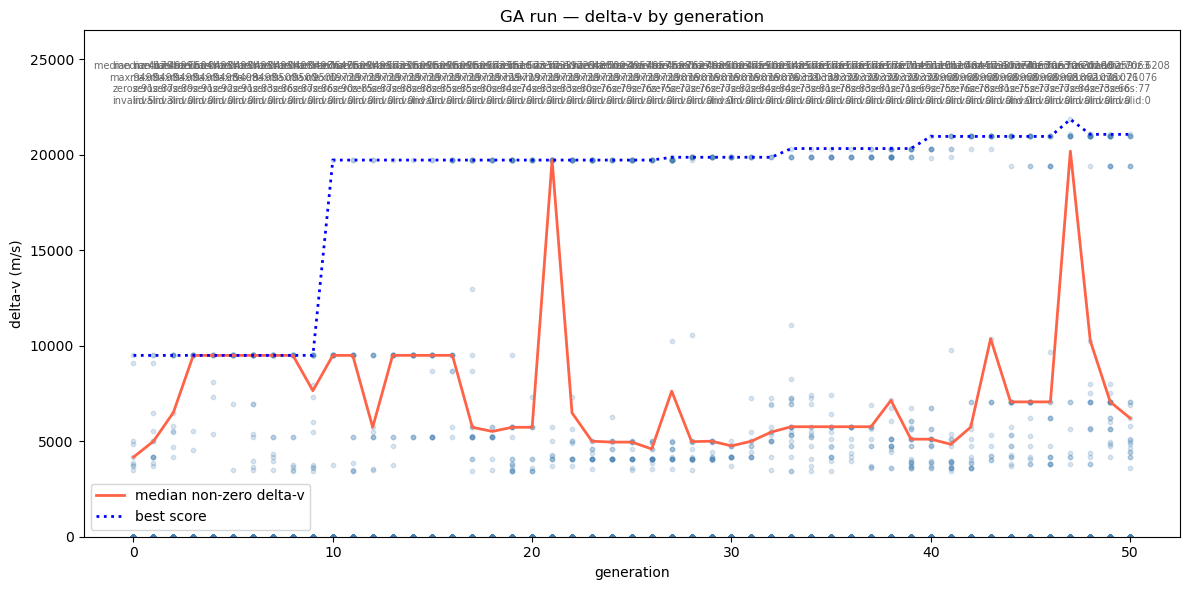

In [62]:
# plot
import src.plots
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

src.plots.plot_run(run_dir)

In [48]:
# analyze
from src.analysis import analyze_population

analysis = analyze_population(result, top_n=10, verbose=True)

Top 10 mean score:  17,735 m/s  (7.34x population mean of 2,417 m/s)
Top 10 max score:   21,076 m/s  |  Pop max: 21,076 m/s
Pop zeros: 77.0%  |  Top zeros: 0.0%
Avg stages — top: 3.2  |  pop: 4.4
Top stage dist: 3-stage: 8  4-stage: 2
Avg parts  — top: 9.6  |  pop: 13.3
Top engine (top 10): toroidalAerospike (11 uses)
Top tank   (top 10): fuelTankSmall (10 uses)
Top pod    (top 10): cupola (10 uses)


In [ ]:
from src.analysis import inspect_top_rockets

inspect_top_rockets(
    "/Users/moss/Desktop/Personal_documents/repos/to_the_mun/data/runs/run_2026-04-03-145251",
    top_n=5,
)

section to generate and plug into the harness

In [ ]:
from pathlib import Path
from src.config import load_parts_by_name
from src.craft import to_craft

parts_by_name = load_parts_by_name()
test_rocket = {
    "parts": [
        {"id": "pod_0", "type": "probeCoreOcto_v2", "parent": None, "attach_node": None},
        {"id": "tank_0", "type": "adapterSize2-Size1", "parent": "pod_0", "attach_node": "bottom"},
        {"id": "eng_0", "type": "microEngine_v2", "parent": "tank_0", "attach_node": "bottom"},
        {"id": "decoupler_0", "type": "Decoupler_0", "parent": "eng_0", "attach_node": "bottom"},
        {"id": "tank_1", "type": "Size3SmallTank", "parent": "decoupler_0", "attach_node": "bottom"},
        {"id": "eng_1", "type": "Size2LFB_v2", "parent": "tank_1", "attach_node": "bottom"},
    ],
    "stages": {
        "eng_0": 0,
        "decoupler_0": 1,
        "eng_1": 1,
    }
}

craft_text, meta = to_craft(test_rocket, parts_by_name, ship_name="GeneratedTest")
print(meta)
out_path = Path("/Users/moss/Library/Application Support/Steam/steamapps/common/Kerbal Space Program/saves/MSandbox/Ships/VAB/GeneratedTest.craft")
out_path.write_text(craft_text)
print(out_path)